In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv("q1.csv", header=None)
df.describe()
df.head()

,0
0,0.8402
1,1.0644
2,1.1298
3,1.4314
4,1.7795


In [3]:
#Assessing goodness of fit to Weibull using Q-Q plot

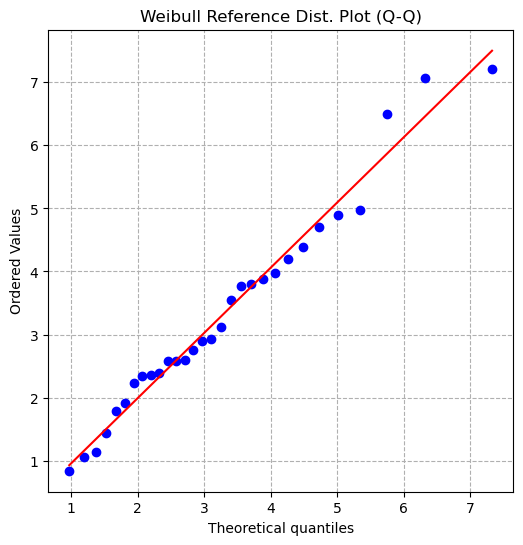

In [4]:
shape, loc, scale = stats.weibull_min.fit(df)
plt.figure(figsize=(6,6))
stats.probplot(df[0], sparams=(shape, loc, scale), dist="weibull_min", plot=plt)
plt.title("Weibull Reference Dist. Plot (Q-Q)")
plt.grid(True, linestyle='--')
plt.show()

In [5]:
#Formal GoF via Anderson-Darling

In [6]:
AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)])

C:\Users\jmeek\AppData\Local\Temp\ipykernel_21440\506921784.py:1: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)])


In [7]:
AD.pvalue #Capped at 0.25, but passes

np.float64(0.25)

In [8]:
#Testing uncapped P-value
AD = stats.anderson_ksamp([df[0], stats.weibull_min.rvs(shape, loc, scale, size = 1000)], method = stats.PermutationMethod(n_resamples=2000))

In [9]:
AD.pvalue

np.float64(0.9500249875062469)

In [10]:
#Assuming the mean number of pollutant particles per cubic meter across the city is 18.4, calculate the
#expected frequencies (Ei) for each group of particle counts based on the Poisson distribution

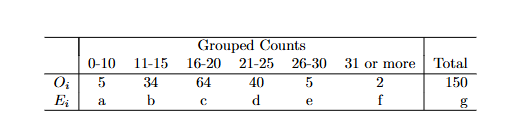

In [11]:
#Assuming the mean number of pollutant particles per cubic meter across the city is 18.4, calculate the
#expected frequencies (Ei) for each group of particle counts based on the Poisson distribution
rate = 18.4
n = 150
pA = stats.poisson.cdf(10, rate)
pB = stats.poisson.cdf(15, rate) - stats.poisson.cdf(10, rate)
pC = stats.poisson.cdf(20, rate) - stats.poisson.cdf(15, rate)
pD = stats.poisson.cdf(25, rate) - stats.poisson.cdf(20, rate)
pE = stats.poisson.cdf(30, rate) - stats.poisson.cdf(25, rate)
pF = 1 - stats.poisson.cdf(30, rate)

eA = pA * n
eB = pB * n
eC = pC * n
eD = pD * n
eE = pE * n
eF = pF * n

GroupedCounts = {
    'Group': ['0-10', '11-15', '16-20', '21-25', '26-30', '31+'],
    'Observed': [5, 34, 64, 40, 5, 2],
    'Expected': [eA, eB, eC, eD, eE, eF]
}
df=pd.DataFrame(GroupedCounts)
print(df)

   Group  Observed   Expected
0   0-10         5   3.731857
1  11-15        34  34.710731
2  16-20        64  66.277242
3  21-25        40  37.056722
4  26-30         5   7.544587
5    31+         2   0.678861


In [12]:
#Using the observed and expected frequencies, conduct a Chi-square goodness-of-fit test to evaluate if
#the Poisson model provides a good fit for the observed data on air pollutant concentration.

In [13]:
df['Chi'] = (df['Observed']-df['Expected'])**2 / df['Expected']
chiStat = df['Chi'].sum()
dof = len(df)-1 #since rate lambda was given
pVal = 1 - stats.chi2.cdf(chiStat, dof)
#alternatively
pVal2 = stats.chi2.sf(chiStat, dof)
print(f"Chi-square goodness-of-fit test for the Poisson model results in a p value of {pVal:.3f}, suggesting the data does indeed follow a Poisson distribution")

Chi-square goodness-of-fit test for the Poisson model results in a p value of 0.523, suggesting the data does indeed follow a Poisson distribution
